In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

                      Model  Accuracy(STS Score)  Inference Time(ms)  \
0          all-MiniLM-L6-v2                 0.84                  10   
2   paraphrase-MiniLM-L6-v2                 0.86                  12   
4  distilbert-base-nli-stsb                 0.83                  15   
1         all-mpnet-base-v2                 0.88                  18   
3  paraphrase-mpnet-base-v2                 0.87                  20   

   Model Size(MB)  Memory Usage(MB)  TOPSIS Score  Rank  
0              90               250      0.945092   1.0  
2             120               300      0.880089   2.0  
4             250               500      0.510614   3.0  
1             420               650      0.134614   4.0  
3             450               700      0.054908   5.0  


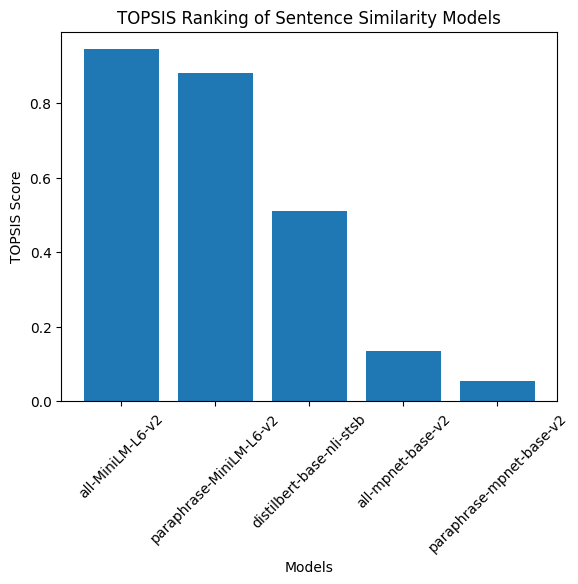

In [2]:


# Step 1: Create DataFrame with sentence similarity models
data = {
    "Model": [
        "all-MiniLM-L6-v2",
        "all-mpnet-base-v2",
        "paraphrase-MiniLM-L6-v2",
        "paraphrase-mpnet-base-v2",
        "distilbert-base-nli-stsb"
    ],

    # Higher is better
    "Accuracy(STS Score)": [0.84, 0.88, 0.86, 0.87, 0.83],

    # Lower is better
    "Inference Time(ms)": [10, 18, 12, 20, 15],

    # Lower is better
    "Model Size(MB)": [90, 420, 120, 450, 250],

    # Lower is better
    "Memory Usage(MB)": [250, 650, 300, 700, 500]
}

df = pd.DataFrame(data)

# Step 2: Extract features
features = df.iloc[:, 1:].values

# Step 3: Normalize decision matrix
norm = features / np.sqrt((features**2).sum(axis=0))

# Step 4: Assign weights
weights = np.array([0.4, 0.2, 0.2, 0.2])

weighted_matrix = norm * weights

# Step 5: Determine ideal best and worst
ideal_best = np.array([
    weighted_matrix[:,0].max(),   # accuracy (benefit)
    weighted_matrix[:,1].min(),   # time (cost)
    weighted_matrix[:,2].min(),   # size (cost)
    weighted_matrix[:,3].min()    # memory (cost)
])

ideal_worst = np.array([
    weighted_matrix[:,0].min(),
    weighted_matrix[:,1].max(),
    weighted_matrix[:,2].max(),
    weighted_matrix[:,3].max()
])

# Step 6: Calculate distances
dist_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

# Step 7: Calculate TOPSIS score
score = dist_worst / (dist_best + dist_worst)

df["TOPSIS Score"] = score
df["Rank"] = df["TOPSIS Score"].rank(ascending=False)

# Sort results
result = df.sort_values("Rank")

print(result)

# Step 8: Plot results
plt.figure()
plt.bar(result["Model"], result["TOPSIS Score"])
plt.xlabel("Models")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Ranking of Sentence Similarity Models")
plt.xticks(rotation=45)
plt.show()